In [1]:
import argparse
import os
import sys
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score, accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

import json

In [2]:
def parse_args():
    defaults = {
        "input_dir": "../../data/embedded",
        "output_dir": "../../data/results",
        "generate_plot": True,
        "algorithm": "kmeans",
        "n_clusters": 5,
        "eps": 10.0,
        "min_samples": 3,
        "reducer": "pca",
        "perplexity": 30.0
    }
    return defaults

In [3]:
def load_data_recursive(input_dir):
    embeddings_list = []
    filenames = []

    print(f"Scanning '{input_dir}' for embeddings...")

    files_found = 0
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.endswith(".npy"):
                file_path = os.path.join(root, file)

                try:
                    data = np.load(file_path)

                    if data.ndim == 0:
                        continue
                    elif data.ndim == 2:
                        data = data.squeeze()

                    if data.shape != (1024,):
                        continue

                    embeddings_list.append(data)
                    filenames.append(file.replace(".npy", ""))
                    files_found += 1

                except Exception as e:
                    print(f"Error loading {file}: {e}")

    if files_found == 0:
        return None, None

    print(f"Found {files_found} valid files.")

    X = np.vstack(embeddings_list)
    return X, filenames

Scanning '../../data/embedded' for embeddings...
Found 16272 valid files.
Final Matrix Shape: (16272, 1024) (Samples: 16272, Features: 1024)
Scaling features...
Running Clustering (kmeans)...
KMeans with 5 clusters
Reducing dimensions using PCA...
Exporting raw data for GUI...
GUI data saved to: ../../data/results\real_chart_data.json

CLUSTERING METRICS
Silhouette Score: 0.0824 (Closer to 1 = better separated)
Purity Accuracy Score: 0.5903 (Evaluated on 16272 core points)
Adjusted Rand Index (ARI): 0.0570 (Closer to 1 = better match to true labels)
Normalized Mutual Info (NMI):  0.0746 (Closer to 1 = more information shared)
              precision    recall  f1-score   support

          CD       0.69      0.32      0.43      1709
         HYP       0.00      0.00      0.00       536
          MI       0.00      0.00      0.00      2538
        NORM       0.59      1.00      0.74      9083
        STTC       0.00      0.00      0.00      2406

    accuracy                           0

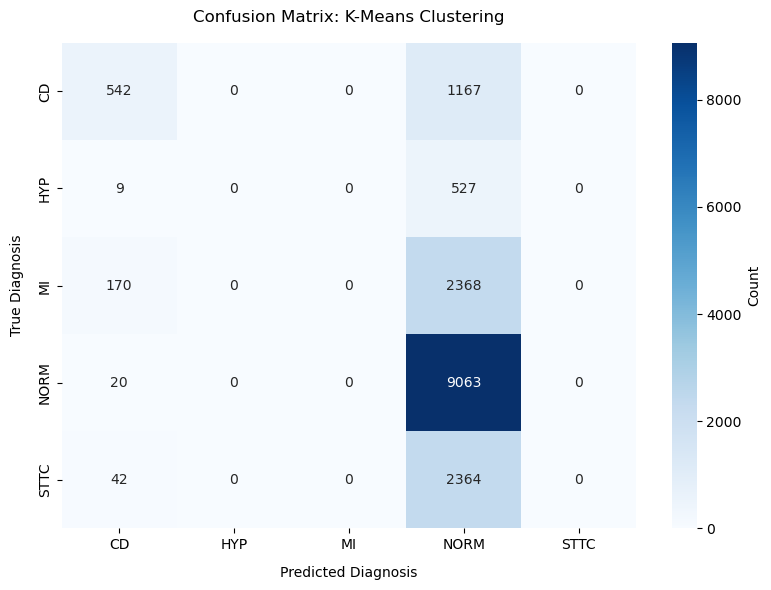

In [6]:
def main():
    args = parse_args()

    # LOAD DATA
    if not os.path.exists(args['input_dir']):
        print(f"Error: Directory '{args['input_dir']}' not found.")
        sys.exit(0)

    os.makedirs(args['output_dir'], exist_ok=True)

    X, file_labels = load_data_recursive(args['input_dir'])

    if X is None:
        print("No valid embeddings found. Check your directory.")
        sys.exit(0)

    print(f"Final Matrix Shape: {X.shape} (Samples: {X.shape[0]}, Features: {X.shape[1]})")

    # PREPROCESSING
    print("Scaling features...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # CLUSTERING
    print(f"Running Clustering ({args['algorithm']})...")

    if args['algorithm'] == "kmeans":
        print(f"KMeans with {args['n_clusters']} clusters")
        model = KMeans(n_clusters=args['n_clusters'], random_state=42, n_init=10)
        labels = model.fit_predict(X_scaled)

    elif args['algorithm'] == "dbscan":
        print(f"DBSCAN with eps={args['eps']}, min_samples={args['min_samples']}")
        model = DBSCAN(eps=args['eps'], min_samples=3)
        labels = model.fit_predict(X_scaled)

    # DIMENSIONALITY REDUCTION
    print(f"Reducing dimensions using {args['reducer'].upper()}...")

    if args['reducer'] == "pca":
        reducer = PCA(n_components=2)
        X_2d = reducer.fit_transform(X_scaled)

    elif args['reducer'] == "tsne":
        pca_50 = PCA(n_components=min(50, X.shape[1]))
        X_pca = pca_50.fit_transform(X_scaled)

        tsne = TSNE(n_components=2, perplexity=args['perplexity'], random_state=42, init='pca', learning_rate='auto')
        X_2d = tsne.fit_transform(X_pca)

    df_plot = pd.DataFrame(X_2d, columns=['Component 1', 'Component 2'])

    df_plot['Cluster'] = labels.astype(str) 
    df_plot['Source'] = file_labels

    df_plot['ecg_id'] = df_plot['Source'].astype(int)

    try:
        true_labels_df = pd.read_csv('../../data/preprocessed/cleaned_labels.csv')
        df_plot = df_plot.merge(true_labels_df[['ecg_id', 'label']], on='ecg_id', how='left')
        df_plot['label'] = df_plot['label'].fillna('Unknown')
    except Exception as e:
        print(f"Could not load true labels: {e}")
        df_plot['label'] = 'Unknown'

    # DATA JSON
    print("Exporting raw data for GUI...")
    
    json_save_path = os.path.join(args['output_dir'], "real_chart_data.json")
    chart_data = []

    for idx, row in df_plot.iterrows():
        chart_data.append({
            "x": row['Component 1'],
            "y": row['Component 2'],
            "cluster": row['Cluster'],
            "source": row['Source'],
            "label": row['label']
        })

    with open(json_save_path, 'w') as f:
        json.dump(chart_data, f, indent=4)

    print(f"GUI data saved to: {json_save_path}")

    # --- CLUSTERING EVALUATION ---
    print("\n" + "="*40)
    print("CLUSTERING METRICS")
    print("="*40)

    # Silhouette Score
    sil_score = silhouette_score(X_scaled, labels)
    print(f"Silhouette Score: {sil_score:.4f} (Closer to 1 = better separated)")

    # External Metrics
    valid_idx = df_plot['label'] != 'Unknown'
    true_labels_valid = df_plot.loc[valid_idx, 'label']
    pred_clusters_valid = df_plot.loc[valid_idx, 'Cluster']

    if len(true_labels_valid) > 0:
        # Calculate ARI and NMI
        ari = adjusted_rand_score(true_labels_valid, pred_clusters_valid)
        nmi = normalized_mutual_info_score(true_labels_valid, pred_clusters_valid)

        mapped_preds = np.zeros(len(pred_clusters_valid), dtype=object)

        for cluster_id in np.unique(pred_clusters_valid):
            if str(cluster_id) == '-1':
                continue
                
            idx = np.where(pred_clusters_valid == cluster_id)[0]
            
            if len(idx) > 0:
                majority_disease = true_labels_valid.iloc[idx].mode()[0]
                mapped_preds[idx] = majority_disease
                
        core_mask = (pred_clusters_valid.astype(str) != '-1').values

        if sum(core_mask) > 0:
            y_true_core = true_labels_valid.iloc[core_mask]
            y_pred_core = mapped_preds[core_mask]
            
            acc = accuracy_score(y_true_core, y_pred_core)
            print(f"Purity Accuracy Score: {acc:.4f} (Evaluated on {sum(core_mask)} core points)")

            unique_classes = sorted(y_true_core.unique())
            cm = confusion_matrix(y_true_core, y_pred_core, labels=unique_classes)
            cm_df = pd.DataFrame(
                cm, 
                index=[f"Valós {c}" for c in unique_classes], 
                columns=[f"Jósolt {c}" for c in unique_classes]
            )
        else:
            print("Purity Accuracy Score: N/A (All points are noise)")
        
        print(f"Adjusted Rand Index (ARI): {ari:.4f} (Closer to 1 = better match to true labels)")
        print(f"Normalized Mutual Info (NMI):  {nmi:.4f} (Closer to 1 = more information shared)")
        print(classification_report(y_true_core, y_pred_core, zero_division=0))
        print(cm_df)
        
        import matplotlib.pyplot as plt
        import seaborn as sns

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=unique_classes, 
                    yticklabels=unique_classes,
                    cbar_kws={'label': 'Count'})

        plt.title(f'Confusion Matrix: K-Means Clustering', pad=15)
        plt.xlabel('Predicted Diagnosis', labelpad=10)
        plt.ylabel('True Diagnosis', labelpad=10)
        plt.tight_layout()

        cm_path_png = os.path.join(args['output_dir'], f"confusion_matrix_{args['algorithm']}_clustering.png")
        plt.savefig(cm_path_png, dpi=300, bbox_inches='tight')
        print(f"Statikus tévesztési mátrix mentve ide: {cm_path_png}")

        plt.show()
    else:
        print("Could not calculate ARI/NMI: No true labels found.")
    
    print("="*40 + "\n")

main()

In [5]:
### main()